# Street Flooding 311 Processing Pipeline

Pipeline reproducible para procesar quejas 311 de inundacion en calles.

Flujo:
- descarga/caché del origen 311,
- limpieza temporal,
- matching espacial contra `data/spatial/vector/streets/processed/lion_metrics.gpkg`,
- fallback textual si no hay coordenadas o si el match espacial falla,
- agregacion temporal por `segment_id`,
- exportacion de `individual_complaints.csv` y `flood_events.csv`.

El notebook intenta primero la vista publica actual de Street Flooding, luego el alias historico `t9hb-ip2a`, y al final cae al dataset general de 311 con filtro de street flooding.


In [2]:

from __future__ import annotations

import os
import re
import sys
import unicodedata
from datetime import date, timedelta
from pathlib import Path
from typing import Iterable

MPLCONFIGDIR = Path('/tmp/matplotlib')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sodapy import Socrata

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook fallback
    display = print

plt.style.use('seaborn-v0_8-whitegrid')


def find_project_root(start: Path | None = None) -> Path:
    """Return the repository root that contains `data/` and `notebooks/`."""
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('No se encontro la raiz del proyecto.')


ROOT = find_project_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from project_name.utils import ensure_directory

CITY_TZ = 'America/New_York'
SOURCE_DATASET_CANDIDATES = ['wymi-u6i8', 't9hb-ip2a', 'erm2-nwe9']
LION_PATH = ROOT / 'data/spatial/vector/streets/processed/lion_metrics.gpkg'
OUTPUT_DIR = ensure_directory(ROOT / 'data/processed/311')
CACHE_DIR = ensure_directory(OUTPUT_DIR / 'cache')
RAW_CACHE_DIR = ensure_directory(CACHE_DIR / 'street_flooding_raw')
INDIVIDUAL_PATH = OUTPUT_DIR / 'individual_complaints.csv'
EVENTS_PATH = OUTPUT_DIR / 'flood_events.csv'
RAW_MASTER_BASE = CACHE_DIR / 'street_flooding_raw_master'
SOURCE_START = '2010-01-01'
SOURCE_END = date.today().isoformat()
MONTHLY_LIMIT = 50_000
MATCH_TOLERANCE_FT = 150.0
HIGH_DISTANCE_FT = 250.0

APP_TOKEN = os.getenv('NYC_APP_TOKEN') or os.getenv('SOCRATA_APP_TOKEN')
DEFAULT_DOMAIN = 'data.cityofnewyork.us'

LION_COLUMNS = ['SegmentID', 'Street', 'SAFStreetName', 'LBoro', 'RBoro', 'edge_id', 'geometry']
BOROUGH_CODE_MAP = {
    '1': 'MANHATTAN',
    '2': 'BRONX',
    '3': 'BROOKLYN',
    '4': 'QUEENS',
    '5': 'STATEN ISLAND',
}
BOROUGH_NORMALIZATION = {
    'MN': 'MANHATTAN',
    'MANHATTAN': 'MANHATTAN',
    'NEW YORK': 'MANHATTAN',
    'NEW YORK COUNTY': 'MANHATTAN',
    'KINGS': 'BROOKLYN',
    'KINGS COUNTY': 'BROOKLYN',
    'BRONX': 'BRONX',
    'BRONX COUNTY': 'BRONX',
    'BX': 'BRONX',
    'BROOKLYN': 'BROOKLYN',
    'BK': 'BROOKLYN',
    'BKLYN': 'BROOKLYN',
    'QUEENS': 'QUEENS',
    'QUEENS COUNTY': 'QUEENS',
    'QN': 'QUEENS',
    'STATEN ISLAND': 'STATEN ISLAND',
    'STATEN ISLAND COUNTY': 'STATEN ISLAND',
    'SI': 'STATEN ISLAND',
    'RICHMOND': 'STATEN ISLAND',
    'RICHMOND COUNTY': 'STATEN ISLAND',
}
ABBREVIATIONS = [
    ('ST', 'STREET'),
    ('AVE', 'AVENUE'),
    ('BLVD', 'BOULEVARD'),
    ('RD', 'ROAD'),
    ('DR', 'DRIVE'),
    ('PL', 'PLACE'),
    ('LN', 'LANE'),
    ('PKWY', 'PARKWAY'),
    ('HWY', 'HIGHWAY'),
    ('E', 'EAST'),
    ('W', 'WEST'),
    ('N', 'NORTH'),
    ('S', 'SOUTH'),
    ('NE', 'NORTHEAST'),
    ('NW', 'NORTHWEST'),
    ('SE', 'SOUTHEAST'),
    ('SW', 'SOUTHWEST'),
]

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)
print(ROOT)
print(OUTPUT_DIR)


/home/map10194/Documents/urban-flood-stress
/home/map10194/Documents/urban-flood-stress/data/processed/311


In [3]:

def month_ranges(start: str, end: str):
    """Yield calendar month windows between two ISO dates."""
    start_dt = pd.Timestamp(start).to_pydatetime().date()
    end_dt = pd.Timestamp(end).to_pydatetime().date()
    cursor = start_dt
    while cursor <= end_dt:
        if cursor.month == 12:
            next_month = date(cursor.year + 1, 1, 1)
        else:
            next_month = date(cursor.year, cursor.month + 1, 1)
        chunk_end = min(next_month, end_dt + timedelta(days=1))
        yield cursor.isoformat(), chunk_end.isoformat(), cursor.strftime('%Y_%m')
        cursor = next_month


def query_socrata_rows(
    client: Socrata,
    dataset_id: str,
    *,
    select: str | None = None,
    where: str | None = None,
    order: str | None = None,
    limit: int = MONTHLY_LIMIT,
) -> pd.DataFrame:
    """Fetch a Socrata query in stable pages."""
    rows: list[dict] = []
    offset = 0
    while True:
        query: dict[str, object] = {'limit': limit, 'offset': offset}
        if select is not None:
            query['select'] = select
        if where is not None:
            query['where'] = where
        if order is not None:
            query['order'] = order
        batch = client.get(dataset_id, **query)
        if not batch:
            break
        rows.extend(batch)
        if len(batch) < limit:
            break
        offset += limit
    return pd.DataFrame.from_records(rows)


def resolve_source_dataset(client: Socrata, candidates: list[str]):
    """Pick the first working Socrata view from a list of candidates."""
    errors: dict[str, Exception] = {}
    for dataset_id in candidates:
        try:
            sample = client.get(dataset_id, limit=1)
            if sample:
                return dataset_id, sample[0]
        except Exception as exc:
            errors[dataset_id] = exc
    message = 'No se pudo resolver una fuente Street Flooding valida.'
    if errors:
        message += ' ' + '; '.join(f'{key}: {type(err).__name__}' for key, err in errors.items())
    raise RuntimeError(message)


def resolve_field(available: Iterable[str], *candidates: str) -> str | None:
    """Return the first available field name from a list of candidates."""
    available_list = [str(col) for col in available]
    available_set = set(available_list)
    available_lower = {str(col).lower(): str(col) for col in available_list}
    for candidate in candidates:
        if candidate in available_set:
            return candidate
        lowered = candidate.lower()
        if lowered in available_lower:
            return available_lower[lowered]
    return None


def infer_field_map(available: Iterable[str], source_id: str | None = None) -> dict[str, str | None]:
    """Infer the source field map from the available columns."""
    available = list(available)
    return {
        'source_id': source_id,
        'created': resolve_field(available, 'created_date', 'created', 'date_created', 'open_date', 'date'),
        'unique': resolve_field(available, 'unique_key', 'id', 'complaint_id', 'service_request_id'),
        'closed': resolve_field(available, 'closed_date', 'resolved_date', 'closed', 'resolution_date'),
        'status': resolve_field(available, 'status', 'complaint_status'),
        'borough': resolve_field(available, 'borough', 'boro'),
        'complaint': resolve_field(available, 'complaint_type', 'complaint'),
        'descriptor': resolve_field(available, 'descriptor', 'description'),
        'street': resolve_field(available, 'street_name', 'street', 'incident_address'),
        'latitude': resolve_field(available, 'latitude', 'lat'),
        'longitude': resolve_field(available, 'longitude', 'lon', 'lng'),
        'x': resolve_field(available, 'x_coordinate_state_plane', 'x_coordinate', 'x'),
        'y': resolve_field(available, 'y_coordinate_state_plane', 'y_coordinate', 'y'),
        'incident_zip': resolve_field(available, 'incident_zip', 'zip'),
        'location': resolve_field(available, 'location'),
    }


def cached_frame_path(base: Path) -> Path | None:
    """Find a cached frame by base name."""
    parquet = base.with_suffix('.parquet')
    csv = base.with_suffix('.csv')
    if parquet.exists():
        return parquet
    if csv.exists():
        return csv
    return None


def write_cached_frame(frame: pd.DataFrame, base: Path) -> Path:
    """Persist a frame as parquet when available, else CSV."""
    try:
        path = base.with_suffix('.parquet')
        frame.to_parquet(path, index=False)
        return path
    except Exception:
        path = base.with_suffix('.csv')
        frame.to_csv(path, index=False)
        return path


def read_cached_frame(path: Path) -> pd.DataFrame:
    """Read a cached frame from parquet or CSV."""
    if path.suffix == '.parquet':
        return pd.read_parquet(path)
    return pd.read_csv(path, low_memory=False)


def build_street_flood_where(complaint_field: str | None, descriptor_field: str | None) -> str | None:
    """Build a permissive street flooding filter from text fields."""
    clauses = []
    for field in [complaint_field, descriptor_field]:
        if not field:
            continue
        expr = f"upper(coalesce(`{field}`, ''))"
        clauses.append(
            '(' + ' OR '.join([
                f"{expr} LIKE '%STREET FLOOD%'",
                f"{expr} LIKE '%FLOODED STREET%'",
                f"{expr} LIKE '%FLOOD%STREET%'",
                f"{expr} LIKE '%INUND%CALLE%'",
                f"{expr} LIKE '%CALLE%INUND%'",
            ]) + ')'
        )
    if not clauses:
        return None
    return ' OR '.join(clauses)


def build_order_clause(created_field: str, unique_field: str | None) -> str:
    """Return a stable order clause for paging."""
    if unique_field:
        return f'`{created_field}` ASC, `{unique_field}` ASC'
    return f'`{created_field}` ASC'


def parse_timestamp_series(series: pd.Series) -> pd.Series:
    """Parse timestamps and convert them to NYC time."""
    return pd.to_datetime(
        series,
        errors='coerce',
        utc=True,
    ).dt.tz_convert(CITY_TZ)


def clean_text(value) -> str | None:
    """Normalize text for street and borough matching."""
    if value is None or pd.isna(value):
        return pd.NA
    text = unicodedata.normalize('NFKD', str(value))
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = text.upper().strip()
    text = text.replace('&', ' AND ')
    text = re.sub(r'[\.,;/_@\-]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if not text:
        return pd.NA

    parts = text.split()
    if len(parts) >= 3 and re.fullmatch(r'[\d\-]+', parts[0]):
        text = ' '.join(parts[1:])

    for abbr, full in ABBREVIATIONS:
        text = re.sub(rf'\b{re.escape(abbr)}\b', full, text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text or pd.NA


def normalize_borough(value) -> str | None:
    """Normalize borough names to a canonical NYC form."""
    text = clean_text(value)
    if pd.isna(text):
        return pd.NA
    return BOROUGH_NORMALIZATION.get(str(text), str(text))


def first_nonempty(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    """Return the first non-empty string across a list of columns."""
    out = pd.Series(pd.NA, index=frame.index, dtype='string')
    for column in columns:
        if column in frame.columns:
            series = frame[column].astype('string')
            out = out.fillna(series.where(series.str.strip().ne('')))
    return out


In [4]:

def download_or_load_raw_street_flooding() -> tuple[pd.DataFrame, dict[str, str | None], str]:
    """Download the source 311 rows in monthly batches and cache the result."""
    master_path = cached_frame_path(RAW_MASTER_BASE)
    if master_path is not None:
        raw = read_cached_frame(master_path)
        source_id = 'cached'
        if 'source_id' in raw.columns and raw['source_id'].notna().any():
            source_id = raw['source_id'].dropna().astype('string').iloc[0]
        field_map = infer_field_map(raw.columns, source_id)
        raw.attrs['source_id'] = source_id
        raw.attrs['field_map'] = field_map
        return raw, field_map, source_id

    client = Socrata(DEFAULT_DOMAIN, APP_TOKEN, timeout=120)
    source_id, sample = resolve_source_dataset(client, SOURCE_DATASET_CANDIDATES)
    available_columns = list(sample.keys())
    field_map = infer_field_map(available_columns, source_id)

    created_field = field_map['created']
    if created_field is None:
        raise RuntimeError(f'No se encontro un campo de inicio de la queja en {source_id}.')

    unique_field = field_map['unique']
    closed_field = field_map['closed']
    status_field = field_map['status']
    borough_field = field_map['borough']
    complaint_field = field_map['complaint']
    descriptor_field = field_map['descriptor']
    street_field = field_map['street']
    latitude_field = field_map['latitude']
    longitude_field = field_map['longitude']
    x_field = field_map['x']
    y_field = field_map['y']
    incident_zip_field = field_map['incident_zip']
    location_field = field_map['location']

    select_fields = [field for field in [
        unique_field, created_field, closed_field, status_field, borough_field,
        complaint_field, descriptor_field, street_field, latitude_field, longitude_field,
        x_field, y_field, incident_zip_field, location_field,
    ] if field]
    select = ','.join(f'`{field}`' for field in dict.fromkeys(select_fields)) if select_fields else None
    order = build_order_clause(created_field, unique_field)
    flood_where = build_street_flood_where(complaint_field, descriptor_field)

    batches: list[pd.DataFrame] = []
    source_cache_dir = ensure_directory(RAW_CACHE_DIR / source_id)
    for start, end, tag in month_ranges(SOURCE_START, SOURCE_END):
        cache_base = source_cache_dir / f'{source_id}_{tag}'
        cached_path = cached_frame_path(cache_base)
        if cached_path is not None:
            batches.append(read_cached_frame(cached_path))
            continue

        where_parts = [
            f"`{created_field}` >= '{start}T00:00:00'",
            f"`{created_field}` < '{end}T00:00:00'",
        ]
        if flood_where:
            where_parts.append(f'({flood_where})')
        where = ' AND '.join(where_parts)

        frame = query_socrata_rows(
            client,
            source_id,
            select=select,
            where=where,
            order=order,
            limit=MONTHLY_LIMIT,
        )
        if frame.empty:
            continue
        frame['source_id'] = source_id
        frame['source_window'] = tag
        write_cached_frame(frame, cache_base)
        batches.append(frame)

    if not batches:
        raise RuntimeError('No se descargaron filas de Street Flooding.')

    raw = pd.concat(batches, ignore_index=True)
    if unique_field and unique_field in raw.columns:
        raw = raw.drop_duplicates(subset=[unique_field])
    else:
        raw = raw.drop_duplicates()

    raw = raw.reset_index(drop=True)
    raw.attrs['source_id'] = source_id
    raw.attrs['field_map'] = field_map
    write_cached_frame(raw, RAW_MASTER_BASE)
    return raw, field_map, source_id


In [5]:

def build_lion_lookup() -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame, pd.DataFrame, pd.DataFrame]:
    """Load LION metrics, collapse duplicate SegmentID rows, and build text lookups."""
    try:
        lion = gpd.read_file(LION_PATH, columns=LION_COLUMNS).copy()
    except TypeError:
        lion = gpd.read_file(LION_PATH).copy()
        lion = lion[[col for col in LION_COLUMNS if col in lion.columns]].copy()

    lion['segment_id'] = lion['SegmentID'].astype('string')
    lion['borough_left'] = lion['LBoro'].astype('string').map(BOROUGH_CODE_MAP)
    lion['borough_right'] = lion['RBoro'].astype('string').map(BOROUGH_CODE_MAP)
    lion = lion[lion['segment_id'].notna()].copy()

    lion_unique = lion.sort_values(['edge_id', 'segment_id']).drop_duplicates('segment_id').copy()
    lion_unique = gpd.GeoDataFrame(lion_unique[['segment_id', 'Street', 'SAFStreetName', 'LBoro', 'RBoro', 'edge_id', 'geometry']],
                                   geometry='geometry', crs=lion.crs)

    print(f'LION rows: {len(lion):,}')
    print(f'Unique SegmentID values: {len(lion_unique):,}')
    print(f'Collapsed duplicates: {len(lion) - len(lion_unique):,}')

    text_candidates = []
    for name_col in ['Street', 'SAFStreetName']:
        temp = lion[['segment_id', 'LBoro', 'RBoro', name_col]].copy()
        temp['normalized_street_name'] = temp[name_col].map(clean_text)
        temp = temp[temp['normalized_street_name'].notna()].copy()
        temp['borough_left'] = temp['LBoro'].astype('string').map(BOROUGH_CODE_MAP)
        temp['borough_right'] = temp['RBoro'].astype('string').map(BOROUGH_CODE_MAP)
        long = temp.melt(
            id_vars=['segment_id', 'normalized_street_name'],
            value_vars=['borough_left', 'borough_right'],
            value_name='borough_normalized',
        )
        long = long[['segment_id', 'normalized_street_name', 'borough_normalized']].dropna()
        text_candidates.append(long)

    text_candidates = pd.concat(text_candidates, ignore_index=True).drop_duplicates()

    borough_lookup = (
        text_candidates
        .groupby(['normalized_street_name', 'borough_normalized'], as_index=False)
        .agg(
            n_segments=('segment_id', 'nunique'),
            segment_id=('segment_id', lambda s: s.iloc[0] if s.nunique() == 1 else pd.NA),
        )
    )
    borough_lookup = borough_lookup[borough_lookup['segment_id'].notna()].copy()

    global_lookup = (
        text_candidates
        .groupby(['normalized_street_name'], as_index=False)
        .agg(
            n_segments=('segment_id', 'nunique'),
            segment_id=('segment_id', lambda s: s.iloc[0] if s.nunique() == 1 else pd.NA),
        )
    )
    global_lookup = global_lookup[global_lookup['segment_id'].notna()].copy()

    return lion, lion_unique, borough_lookup, global_lookup


In [6]:

def build_complaint_geometry(frame: pd.DataFrame, field_map: dict[str, str | None], lion_crs) -> tuple[pd.DataFrame, dict[str, int]]:
    """Create point geometries from latitude/longitude or state-plane coordinates."""
    out = frame.copy()
    out['geometry'] = None
    coordinate_source = pd.Series(pd.NA, index=out.index, dtype='string')

    lat_field = field_map.get('latitude')
    lon_field = field_map.get('longitude')
    x_field = field_map.get('x')
    y_field = field_map.get('y')

    latlon_valid = pd.Series(False, index=out.index)
    if lat_field and lon_field and lat_field in out.columns and lon_field in out.columns:
        lat = pd.to_numeric(out[lat_field], errors='coerce')
        lon = pd.to_numeric(out[lon_field], errors='coerce')
        latlon_valid = lat.between(-90, 90) & lon.between(-180, 180)
        if latlon_valid.any():
            latlon_gdf = gpd.GeoDataFrame(
                out.loc[latlon_valid].copy(),
                geometry=gpd.points_from_xy(lon.loc[latlon_valid], lat.loc[latlon_valid]),
                crs='EPSG:4326',
            ).to_crs(lion_crs)
            out.loc[latlon_valid, 'geometry'] = latlon_gdf.geometry.values
            coordinate_source.loc[latlon_valid] = 'latlon'
            out['latitude'] = lat
            out['longitude'] = lon

    stateplane_valid = pd.Series(False, index=out.index)
    if x_field and y_field and x_field in out.columns and y_field in out.columns:
        x = pd.to_numeric(out[x_field], errors='coerce')
        y = pd.to_numeric(out[y_field], errors='coerce')
        stateplane_valid = x.notna() & y.notna() & ~latlon_valid
        if stateplane_valid.any():
            state_gdf = gpd.GeoDataFrame(
                out.loc[stateplane_valid].copy(),
                geometry=gpd.points_from_xy(x.loc[stateplane_valid], y.loc[stateplane_valid]),
                crs=lion_crs,
            )
            out.loc[stateplane_valid, 'geometry'] = state_gdf.geometry.values
            coordinate_source.loc[stateplane_valid] = 'state_plane'
            out['x_coordinate_state_plane'] = x
            out['y_coordinate_state_plane'] = y

    stats = {
        'has_coordinates': int((latlon_valid | stateplane_valid).sum()),
        'latlon_coordinates': int(latlon_valid.sum()),
        'stateplane_coordinates': int(stateplane_valid.sum()),
    }
    out['coordinate_source'] = coordinate_source
    out['has_valid_coordinates'] = out['geometry'].notna()
    return out, stats


def assign_segment_by_spatial_match(complaints: gpd.GeoDataFrame, lion_unique: gpd.GeoDataFrame) -> pd.DataFrame:
    """Assign segment ids with direct intersection first, then nearest-neighbor."""
    geo = complaints[complaints['geometry'].notna()].copy()
    if geo.empty:
        return pd.DataFrame(columns=['complaint_id', 'segment_id', 'match_method', 'match_distance'])

    geo = gpd.GeoDataFrame(geo, geometry='geometry', crs=lion_unique.crs)
    lion_basic = lion_unique[['segment_id', 'geometry']].copy()

    direct = gpd.sjoin(geo, lion_basic, how='left', predicate='intersects')
    direct = direct[['complaint_id', 'segment_id']].dropna(subset=['segment_id']).copy()
    direct['match_method'] = 'spatial_intersection'
    direct['match_distance'] = 0.0
    direct = direct.drop_duplicates(subset=['complaint_id'], keep='first')

    matched_ids = set(direct['complaint_id'].tolist())
    remaining = geo.loc[~geo['complaint_id'].isin(matched_ids)].copy()
    if not remaining.empty:
        nearest = gpd.sjoin_nearest(
            remaining,
            lion_basic,
            how='left',
            distance_col='match_distance',
            max_distance=MATCH_TOLERANCE_FT,
        )
        nearest = nearest[['complaint_id', 'segment_id', 'match_distance']].dropna(subset=['segment_id']).copy()
        nearest['match_method'] = 'spatial_nearest'
    else:
        nearest = pd.DataFrame(columns=['complaint_id', 'segment_id', 'match_method', 'match_distance'])

    matched = pd.concat([direct, nearest], ignore_index=True)
    matched = matched.drop_duplicates(subset=['complaint_id'], keep='first')
    return matched


def assign_segment_by_text(
    complaints: pd.DataFrame,
    borough_lookup: pd.DataFrame,
    global_lookup: pd.DataFrame,
) -> pd.DataFrame:
    """Assign segment ids from normalized street names and boroughs."""
    out = complaints.copy()
    out['segment_id'] = pd.NA
    out['match_method'] = pd.NA
    out['match_distance'] = np.nan

    street_source = first_nonempty(out, ['street_name', 'incident_address', 'descriptor'])
    out['normalized_street_name'] = street_source.map(clean_text)
    out['borough_normalized'] = out['borough'].map(normalize_borough) if 'borough' in out.columns else pd.Series(pd.NA, index=out.index)

    borough_join = out.merge(
        borough_lookup[['normalized_street_name', 'borough_normalized', 'segment_id']],
        on=['normalized_street_name', 'borough_normalized'],
        how='left',
        suffixes=('', '_text'),
    )
    borough_join['segment_id'] = borough_join['segment_id'].fillna(borough_join['segment_id_text'])
    borough_join['match_method'] = borough_join['match_method'].fillna('textual_unique')

    unresolved = borough_join['segment_id'].isna()
    if unresolved.any():
        global_join = borough_join.loc[unresolved].merge(
            global_lookup[['normalized_street_name', 'segment_id']],
            on='normalized_street_name',
            how='left',
            suffixes=('', '_global'),
        )
        borough_join.loc[unresolved, 'segment_id'] = global_join['segment_id'].fillna(global_join['segment_id_global']).values
        borough_join.loc[unresolved, 'match_method'] = borough_join.loc[unresolved, 'match_method'].fillna('textual_unique')

    borough_join = borough_join[['segment_id', 'match_method', 'match_distance', 'normalized_street_name', 'borough_normalized']].copy()
    return borough_join


In [7]:

def prepare_individual_complaints() -> tuple[pd.DataFrame, dict[str, int], dict[str, str | None], str]:
    """Build the complaint-level table with spatial and textual matching."""
    cached = pd.read_csv(INDIVIDUAL_PATH, low_memory=False) if INDIVIDUAL_PATH.exists() else None
    if cached is not None and {'complaint_id', 'segment_id', 'start', 'status'}.issubset(cached.columns):
        cached = cached.copy()
        if 'end' not in cached.columns:
            cached['end'] = pd.NaT
        source_id = 'cached'
        if 'source_id' in cached.columns and cached['source_id'].notna().any():
            source_id = cached['source_id'].dropna().astype('string').iloc[0]
        elif cached.attrs.get('source_id'):
            source_id = str(cached.attrs['source_id'])
        field_map = infer_field_map(cached.columns, source_id)
        cached['start'] = pd.to_datetime(
            cached['start'],
            errors='coerce',
            utc=True,
        ).dt.tz_convert(CITY_TZ)

        cached['end'] = pd.to_datetime(
            cached['end'],
            errors='coerce',
            utc=True,
        ).dt.tz_convert(CITY_TZ)
        cached['segment_id'] = cached['segment_id'].astype('string')
        cached['match_method'] = cached['match_method'].astype('string') if 'match_method' in cached.columns else pd.Series(pd.NA, index=cached.index, dtype='string')
        cached['match_distance'] = pd.to_numeric(cached['match_distance'], errors='coerce') if 'match_distance' in cached.columns else pd.Series(np.nan, index=cached.index)
        cached['status'] = pd.to_numeric(cached['status'], errors='coerce').fillna(0).astype('int8')
        for column in [
            'normalized_street_name',
            'borough_normalized',
            'borough',
            'street_name_raw',
            'status_text',
            'coordinate_source',
            'has_valid_coordinates',
            'latitude',
            'longitude',
            'x_coordinate_state_plane',
            'y_coordinate_state_plane',
            'source_id',
            'source_window',
        ]:
            if column not in cached.columns:
                cached[column] = pd.NA
        cached['source_id'] = cached['source_id'].fillna(source_id)
        return cached, {}, field_map, source_id

    raw, field_map, source_id = download_or_load_raw_street_flooding()
    lion, lion_unique, borough_lookup, global_lookup = build_lion_lookup()

    work = raw.copy()
    unique_field = field_map.get('unique')
    if unique_field and unique_field in work.columns:
        work['source_complaint_id'] = work[unique_field].astype('string')
    else:
        work['source_complaint_id'] = work.index.to_series().astype('string')

    complaint_text = first_nonempty(
        work,
        [c for c in [field_map.get('complaint'), field_map.get('descriptor'), field_map.get('street'), field_map.get('location')] if c],
    )
    flood_mask = complaint_text.fillna('').str.contains(r'STREET.*FLOOD|FLOOD.*STREET|FLOODED STREET|INUND.*CALLE|CALLE.*INUND', case=False, regex=True, na=False)
    if flood_mask.any():
        work = work.loc[flood_mask].copy()

    work['start'] = parse_timestamp_series(work[field_map['created']])

    if field_map.get('closed') and field_map['closed'] in work.columns:
        work['end'] = parse_timestamp_series(work[field_map['closed']])
    else:
        work['end'] = pd.Series(pd.NaT, index=work.index, dtype=work['start'].dtype)

    # Force identical timezone-aware dtype
    work['start'] = pd.to_datetime(work['start'], utc=True).dt.tz_convert(CITY_TZ)
    work['end'] = pd.to_datetime(work['end'], utc=True).dt.tz_convert(CITY_TZ)

    work['status_text'] = work[field_map['status']].astype('string') if field_map.get('status') and field_map['status'] in work.columns else pd.NA
    work['status'] = work['end'].notna().astype('int8')
    if field_map.get('borough') and field_map['borough'] in work.columns:
        work['borough'] = work[field_map['borough']].astype('string')
    else:
        work['borough'] = pd.NA

    work['street_name_raw'] = first_nonempty(work, [c for c in [field_map.get('street'), field_map.get('descriptor')] if c])
    work['normalized_street_name'] = work['street_name_raw'].map(clean_text)
    work['borough_normalized'] = work['borough'].map(normalize_borough)

    before_clean = len(work)
    work = work.dropna(subset=['start']).copy()
    invalid_start_count = before_clean - len(work)

    invalid_end = work['end'].notna() & (work['start'] > work['end'])
    invalid_end_count = int(invalid_end.sum())
    work = work.loc[~invalid_end].copy()

    before_dedupe = len(work)
    work = work.drop_duplicates(subset=['source_complaint_id']).copy()
    work['complaint_id'] = np.arange(1, len(work) + 1, dtype='int64')
    dedupe_count = before_dedupe - len(work)

    work, coord_stats = build_complaint_geometry(work, field_map, lion_unique.crs)

    spatial_matches = assign_segment_by_spatial_match(gpd.GeoDataFrame(work, geometry='geometry', crs=lion_unique.crs), lion_unique)
    work = work.merge(spatial_matches, on='complaint_id', how='left', suffixes=('', '_spatial'))
    work['segment_id'] = work['segment_id'].astype('string')
    work['match_method'] = work['match_method'].astype('string')
    work['match_distance'] = pd.to_numeric(work['match_distance'], errors='coerce')

    unmatched = work['segment_id'].isna()
    if unmatched.any():
        text_matches = assign_segment_by_text(work.loc[unmatched].copy(), borough_lookup, global_lookup)
        work.loc[unmatched, 'segment_id'] = text_matches['segment_id'].values
        work.loc[unmatched, 'match_method'] = text_matches['match_method'].values
        work.loc[unmatched, 'match_distance'] = text_matches['match_distance'].values
        work.loc[unmatched, 'normalized_street_name'] = text_matches['normalized_street_name'].values
        work.loc[unmatched, 'borough_normalized'] = text_matches['borough_normalized'].values

    work['segment_id'] = work['segment_id'].astype('string')
    work['match_method'] = work['match_method'].fillna('unmatched').astype('string')
    work['match_distance'] = pd.to_numeric(work['match_distance'], errors='coerce')
    work['start'] = pd.to_datetime(
    work['start'],
        errors='coerce',
        utc=True,
    ).dt.tz_convert(CITY_TZ)

    work['end'] = pd.to_datetime(
        work['end'],
        errors='coerce',
        utc=True,
    ).dt.tz_convert(CITY_TZ)
    work['status'] = work['end'].notna().astype('int8')
    # work['complaint_id'] = np.arange(1, len(work) + 1, dtype='int64')

    desired_columns = [
        'complaint_id', 'source_complaint_id', 'start', 'end', 'segment_id', 'status',
        'match_method', 'match_distance', 'normalized_street_name', 'borough_normalized',
        'borough', 'street_name_raw', 'status_text', 'coordinate_source', 'has_valid_coordinates',
        'latitude', 'longitude', 'x_coordinate_state_plane', 'y_coordinate_state_plane',
        'source_id', 'source_window',
    ]
    for extra_col in ['source_id', 'source_window']:
        if extra_col not in work.columns:
            work[extra_col] = source_id if extra_col == 'source_id' else pd.NA
    output = work[[col for col in desired_columns if col in work.columns]].copy()

    output.to_csv(INDIVIDUAL_PATH, index=False)

    stats = {
        'source_rows': int(len(raw)),
        'filtered_rows': int(len(work)),
        'invalid_start_rows': int(invalid_start_count),
        'invalid_end_rows': int(invalid_end_count),
        'deduplicated_rows': int(dedupe_count),
        'coordinate_rows': int(coord_stats['has_coordinates']),
        'latlon_rows': int(coord_stats['latlon_coordinates']),
        'stateplane_rows': int(coord_stats['stateplane_coordinates']),
        'spatial_matches': int(work['match_method'].isin(['spatial_intersection', 'spatial_nearest']).sum()),
        'text_matches': int(work['match_method'].eq('textual_unique').sum()),
        'unmatched_rows': int(work['segment_id'].isna().sum()),
    }
    return output, stats, field_map, source_id


In [8]:

def merge_segment_intervals(frame: pd.DataFrame) -> pd.DataFrame:
    """Merge overlapping complaint intervals for one segment."""
    columns = ['segment_id', 'segment_event_id', 'start', 'end', 'n_complaints', 'n_open_complaints', 'n_closed_complaints', 'status']
    if frame.empty:
        return pd.DataFrame(columns=columns)

    group = frame.sort_values(['start', 'end'], kind='stable').reset_index(drop=True).copy()
    start_ns = group['start'].astype('int64').to_numpy()
    end_ns = group['end'].astype('int64').to_numpy()
    end_fill = np.where(group['end'].isna().to_numpy(), np.iinfo(np.int64).max, end_ns)
    running_max = np.maximum.accumulate(end_fill)
    previous_max = np.empty_like(running_max)
    previous_max[0] = np.iinfo(np.int64).min
    previous_max[1:] = running_max[:-1]
    new_event = start_ns > previous_max
    group['segment_event_id'] = new_event.cumsum() - 1

    aggregated = (
        group.groupby('segment_event_id', sort=True)
        .agg(
            segment_id=('segment_id', 'first'),
            start=('start', 'min'),
            end=('end', lambda s: pd.NaT if s.isna().any() else s.max()),
            n_complaints=('segment_id', 'size'),
            n_open_complaints=('status', lambda s: int((s == 0).sum())),
            n_closed_complaints=('status', lambda s: int((s == 1).sum())),
        )
        .reset_index()
    )

    aggregated['start'] = pd.to_datetime(
        aggregated['start'],
        utc=True,
    ).dt.tz_convert(CITY_TZ)

    aggregated['end'] = pd.to_datetime(
        aggregated['end'],
        utc=True,
        errors='coerce',
    ).dt.tz_convert(CITY_TZ)

    aggregated['status'] = np.select(
        [aggregated['n_closed_complaints'].eq(0), aggregated['n_open_complaints'].eq(0)],
        [0, 1],
        default=2,
    ).astype('int8')
    return aggregated[columns]


def prepare_flood_events(individual: pd.DataFrame) -> pd.DataFrame:
    """Aggregate complaint intervals into non-overlapping segment events."""
    usable = individual[individual['segment_id'].notna()].copy()
    usable = usable.sort_values(['segment_id', 'start'], kind='stable').reset_index(drop=True)
    print('Aggregation order fixed with:', ['segment_id', 'start'])

    event_parts = []
    for segment_id, group in usable.groupby('segment_id', sort=False):
        merged = merge_segment_intervals(group)
        if not merged.empty:
            event_parts.append(merged)

    if event_parts:
        events = pd.concat(event_parts, ignore_index=True)
    else:
        events = pd.DataFrame(
            columns=['segment_id', 'segment_event_id', 'start', 'end', 'n_complaints', 'n_open_complaints', 'n_closed_complaints', 'status']
        )

    events = events.sort_values(['segment_id', 'start', 'segment_event_id'], kind='stable').reset_index(drop=True)
    events['event_id'] = np.arange(1, len(events) + 1, dtype='int64')
    events = events[['event_id', 'segment_event_id', 'segment_id', 'start', 'end', 'n_complaints', 'n_open_complaints', 'n_closed_complaints', 'status']].copy()
    events.to_csv(EVENTS_PATH, index=False)
    return events


In [9]:
def build_validation_report(individual: pd.DataFrame, events: pd.DataFrame, raw_stats: dict[str, int]) -> pd.DataFrame:
    """Build a compact validation table for the pipeline."""
    total = len(individual)
    matched = int(individual['segment_id'].notna().sum())
    spatial = int(individual['match_method'].isin(['spatial_intersection', 'spatial_nearest']).sum())
    text = int(individual['match_method'].eq('textual_unique').sum())
    unmatched = int(individual['segment_id'].isna().sum())
    high_dist = int((individual['match_distance'] > HIGH_DISTANCE_FT).fillna(False).sum())
    open_complaints = int((individual['status'] == 0).sum())
    closed_complaints = int((individual['status'] == 1).sum())
    invalid_dates = int(individual['start'].isna().sum())
    invalid_event_duration = int(((events['end'].notna()) & (events['end'] < events['start'])).sum()) if not events.empty else 0
    duplicates = int(individual['source_complaint_id'].duplicated().sum()) if 'source_complaint_id' in individual.columns else 0

    rows = [
        ('raw_rows', raw_stats.get('source_rows', len(individual)), 'source rows after download'),
        ('clean_rows', total, 'rows in individual_complaints.csv'),
        ('spatial_match_rate_pct', round((spatial / total) * 100, 2) if total else 0.0, 'direct or nearest spatial matches'),
        ('text_match_rate_pct', round((text / total) * 100, 2) if total else 0.0, 'unique text fallback matches'),
        ('unmatched_rate_pct', round((unmatched / total) * 100, 2) if total else 0.0, 'rows without segment_id'),
        ('high_distance_matches', high_dist, f'matches above {HIGH_DISTANCE_FT} ft'),
        ('open_complaints', open_complaints, 'complaints with end = None'),
        ('closed_complaints', closed_complaints, 'complaints with end timestamp'),
        ('invalid_start_rows', invalid_dates, 'rows with invalid start timestamps'),
        ('duplicate_source_ids', duplicates, 'duplicated source ids after cleaning'),
        ('events_rows', len(events), 'rows in flood_events.csv'),
        ('invalid_event_duration_rows', invalid_event_duration, 'events with negative duration'),
    ]
    return pd.DataFrame(rows, columns=['check', 'value', 'note'])


def plot_event_timelines(individual: pd.DataFrame, events: pd.DataFrame, top_n: int = 3) -> None:
    """Plot example temporal merges for the busiest segments."""
    if individual.empty or events.empty:
        return

    top_segments = (
        events.groupby('segment_id')
        .size()
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )
    if not top_segments:
        return

    fig, axes = plt.subplots(len(top_segments), 1, figsize=(14, 3.2 * len(top_segments)), sharex=True)
    if len(top_segments) == 1:
        axes = [axes]

    for ax, segment_id in zip(axes, top_segments):
        comp = individual[individual['segment_id'] == segment_id].sort_values('start')
        ev = events[events['segment_id'] == segment_id].sort_values('start')

        for _, row in comp.iterrows():
            start = row['start']
            end = row['end'] if pd.notna(row['end']) else start + pd.Timedelta(hours=12)
            ax.broken_barh(
                [(mdates.date2num(start), max((end - start).total_seconds() / 86400.0, 0.01))],
                (0.30, 0.22),
                facecolors='lightgray',
                alpha=0.55,
            )

        for _, row in ev.iterrows():
            start = row['start']
            end = row['end'] if pd.notna(row['end']) else start + pd.Timedelta(hours=12)
            ax.broken_barh(
                [(mdates.date2num(start), max((end - start).total_seconds() / 86400.0, 0.01))],
                (0.62, 0.28),
                facecolors='#3182bd',
                alpha=0.8,
            )

        ax.set_yticks([0.42, 0.76])
        ax.set_yticklabels(['complaints', 'events'])
        ax.set_title(f'Segment {segment_id} | complaints {len(comp)} | events {len(ev)}')
        ax.grid(True, axis='x', alpha=0.25)

    axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
    plt.tight_layout()
    plt.show()


In [10]:
individual_complaints, raw_stats, field_map, source_id = prepare_individual_complaints()
print('source_id:', source_id)
print('individual_complaints:', len(individual_complaints))
print('saved to:', INDIVIDUAL_PATH)

individual_complaints[['complaint_id', 'start', 'end', 'segment_id', 'status', 'match_method']].head()


source_id: t9hb-ip2a
individual_complaints: 6282
saved to: /home/map10194/Documents/urban-flood-stress/data/processed/311/individual_complaints.csv


,complaint_id,start,end,segment_id,status,match_method
0,1,2020-01-03 10:37:00-05:00,NaT,21509.0,0,spatial_nearest
1,2,2020-01-05 08:40:00-05:00,NaT,26502.0,0,spatial_nearest
2,3,2020-01-05 17:39:00-05:00,NaT,31164.0,0,spatial_nearest
3,4,2020-01-06 11:34:00-05:00,NaT,9001638.0,0,spatial_nearest
4,5,2020-01-07 15:01:00-05:00,NaT,29159.0,0,spatial_nearest


In [11]:
flood_events = prepare_flood_events(individual_complaints)
print('flood_events:', len(flood_events))
print('saved to:', EVENTS_PATH)
flood_events[['event_id', 'segment_id', 'start', 'end', 'n_complaints', 'status']].head()


Aggregation order fixed with: ['segment_id', 'start']
flood_events: 3312
saved to: /home/map10194/Documents/urban-flood-stress/data/processed/311/flood_events.csv


,event_id,segment_id,start,end,n_complaints,status
0,1,103598.0,2022-12-23 08:08:00-05:00,NaT,1,0
1,2,103617.0,2025-12-19 08:20:00-05:00,NaT,1,0
2,3,105790.0,2022-12-24 22:08:00-05:00,NaT,1,0
3,4,105803.0,2023-04-30 18:11:00-04:00,NaT,3,0
4,5,105938.0,2025-01-24 16:35:00-05:00,NaT,2,0


In [12]:
validation_report = build_validation_report(individual_complaints, flood_events, raw_stats)
display(validation_report)

summary = pd.DataFrame(
    {
        'metric': [
            'total_complaints',
            'total_events',
            'spatial_match_pct',
            'text_match_pct',
            'unmatched_pct',
            'open_complaints_pct',
            'closed_complaints_pct',
        ],
        'value': [
            len(individual_complaints),
            len(flood_events),
            round(individual_complaints['match_method'].isin(['spatial_intersection', 'spatial_nearest']).mean() * 100, 2),
            round((individual_complaints['match_method'] == 'textual_unique').mean() * 100, 2),
            round(individual_complaints['segment_id'].isna().mean() * 100, 2),
            round((individual_complaints['status'] == 0).mean() * 100, 2),
            round((individual_complaints['status'] == 1).mean() * 100, 2),
        ],
    }
)
display(summary)

matched_only = individual_complaints[individual_complaints['segment_id'].notna()].copy()
matched_only['duration_hours'] = (matched_only['end'] - matched_only['start']).dt.total_seconds() / 3600.0
closed_events = flood_events[flood_events['end'].notna()].copy()
closed_events['duration_hours'] = (closed_events['end'] - closed_events['start']).dt.total_seconds() / 3600.0

print('complaints with coordinates:', int(individual_complaints['has_valid_coordinates'].sum()))
print('spatial matches:', int(individual_complaints['match_method'].isin(['spatial_intersection', 'spatial_nearest']).sum()))
print('text fallback matches:', int(individual_complaints['match_method'].eq('textual_unique').sum()))
print('unmatched complaints:', int(individual_complaints['segment_id'].isna().sum()))
print('events with open complaints:', int((flood_events['status'] == 0).sum()))
print('events with mixed resolution:', int((flood_events['status'] == 2).sum()))

if not closed_events.empty:
    display(closed_events['duration_hours'].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).to_frame('hours'))

print('top segments by event count:')
display(
    flood_events.groupby('segment_id')
    .size()
    .sort_values(ascending=False)
    .head(15)
    .to_frame('events')
)


,check,value,note
0,raw_rows,6282.00,source rows after download
1,clean_rows,6282.00,rows in individual_complaints.csv
2,spatial_match_rate_pct,98.79,direct or nearest spatial matches
3,text_match_rate_pct,1.21,unique text fallback matches
4,unmatched_rate_pct,1.21,rows without segment_id
5,high_distance_matches,0.00,matches above 250.0 ft
6,open_complaints,6282.00,complaints with end = None
7,closed_complaints,0.00,complaints with end timestamp
8,invalid_start_rows,0.00,rows with invalid start timestamps
9,duplicate_source_ids,0.00,duplicated source ids after cleaning


,metric,value
0,total_complaints,6282.00
1,total_events,3312.00
2,spatial_match_pct,98.79
3,text_match_pct,1.21
4,unmatched_pct,1.21
5,open_complaints_pct,100.00
6,closed_complaints_pct,0.00


complaints with coordinates: 6207
spatial matches: 6206
text fallback matches: 76
unmatched complaints: 76
events with open complaints: 3312
events with mixed resolution: 0
top segments by event count:


,events
segment_id,
103598.0,1
103617.0,1
105790.0,1
105803.0,1
105938.0,1
105946.0,1
106007.0,1
106285.0,1
106320.0,1


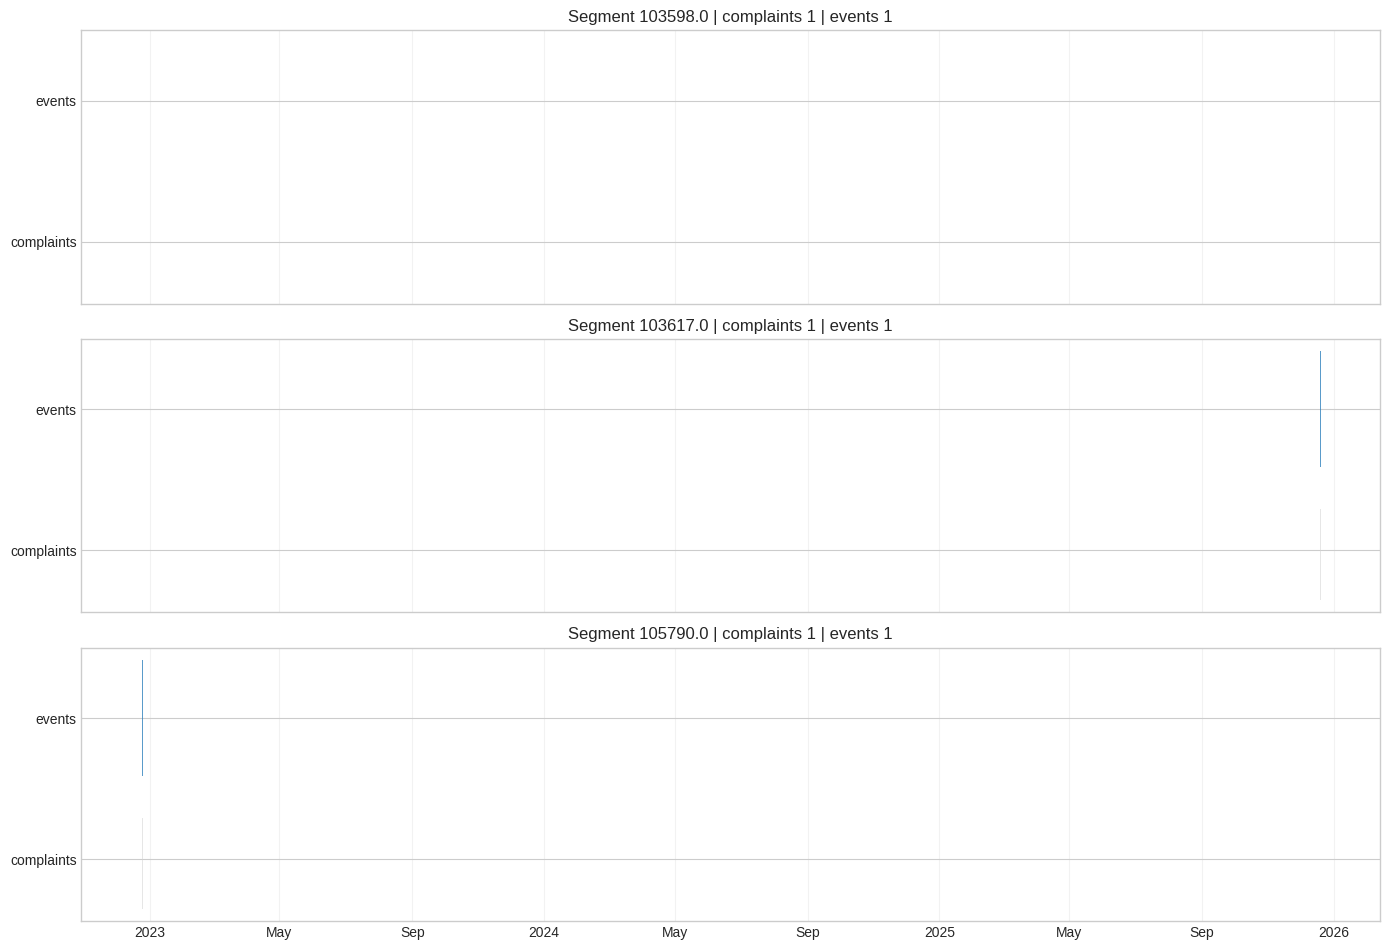

In [13]:
if not closed_events.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(closed_events['duration_hours'].clip(lower=0).dropna(), bins=30, color='#3182bd', alpha=0.85)
    ax.set_title('Flood event duration distribution')
    ax.set_xlabel('Duration (hours)')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

plot_event_timelines(individual_complaints, flood_events, top_n=3)


Text(0.5, 0, 'Number of complaints')

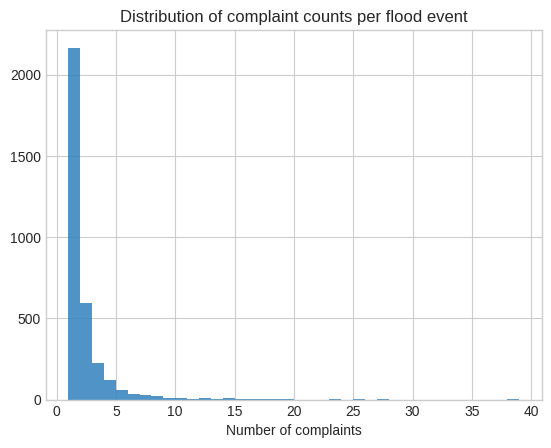

In [14]:
flood_events.hist('n_complaints', bins=range(1, flood_events['n_complaints'].max() + 2), color='#3182bd', alpha=0.85)
plt.title('Distribution of complaint counts per flood event')
plt.xlabel('Number of complaints')  

In [15]:
flood_events

,event_id,segment_event_id,segment_id,start,end,n_complaints,n_open_complaints,n_closed_complaints,status
0,1,0,103598.0,2022-12-23 08:08:00-05:00,NaT,1,1,0,0
1,2,0,103617.0,2025-12-19 08:20:00-05:00,NaT,1,1,0,0
2,3,0,105790.0,2022-12-24 22:08:00-05:00,NaT,1,1,0,0
3,4,0,105803.0,2023-04-30 18:11:00-04:00,NaT,3,3,0,0
4,5,0,105938.0,2025-01-24 16:35:00-05:00,NaT,2,2,0,0
...,...,...,...,...,...,...,...,...,...
3307,3308,0,9009667.0,2021-10-26 09:00:00-04:00,NaT,2,2,0,0
3308,3309,0,9009675.0,2024-02-02 11:11:00-05:00,NaT,1,1,0,0
3309,3310,0,9009680.0,2024-03-06 14:08:00-05:00,NaT,1,1,0,0
3310,3311,0,9009977.0,2021-08-22 21:00:00-04:00,NaT,8,8,0,0
